#### Summary:
In this notebook I will test running FINRICH on different sets of linked cREs, to test for enrichment of GWAS variants. In this case we have credible sets for 6 traits (T1D, T2D, fasting glucose, fasting insulin, 2h glucose, and HbA1c). You can use any credible sets you'd like though!

# 1. Basic Preparation

In [1]:
# Import necessary libraries
suppressMessages(library(dplyr))
suppressMessages(library(stringr))
suppressMessages(library(data.table))
suppressMessages(library(grid))

suppressMessages(library(tictoc))
suppressMessages(library(UpSetR))
suppressMessages(library(ggplot2))
suppressMessages(library(RColorBrewer))
suppressMessages(library(parallel))

In [2]:
# Define celltypes list
celltypes <- c('beta','alpha','delta','gamma','acinar','ductal')

# Define colors for each celltype (same order as celltypes)
colors <- c('#3F98E0', '#F51646', '#E39E14', '#A1D99B', '#F5DE6C', '#09850B')

In [3]:
# Define names and colors for link methods
link_methods <- c('sm', 'sl', 'abc', 'cic')
link_colors <- c('#B35D91', '#56B05C', '#4568A8', '#D8C45E')
names(link_colors) <- link_methods

# Define overlap sets and colors
overlap_colors <- c('sm_sl_abc_cic'='#000000',
                    'sl_abc_cic'='#6E9183','sm_sl_cic'='#A58C77','sm_sl_abc'='#81758A','sm_abc_cic'='#867D90',
                    'sl_cic'='#97BA5D','sl_abc'='#4E8C82','abc_cic'='#8F9683','sm_sl'='#858777','sm_cic'='#C69178','sm_abc'='#7C639D',
                    'sl'='#56B05C','cic'='#D8C45E','abc'='#4568A8','sm'='#B35D91')
link_sets <- names(overlap_colors)

In [4]:
# disable scientific notation for the filepath names of larger distances
options(scipen = 999)
set.seed(8)

### Important file paths

In [5]:
links_dir <- "/dir/with/processed/cRE-gene/links"

In [6]:
overlap_prefix <- file.path(links_dir,'combined/')
overlap_suffix1 <- '_all_methods_sig_links.bedpe'
overlap_suffix2 <- '_all_methods_bg_links.bedpe'

In [7]:
outdir <- '/dir/to/save/outputs/to/FINRICH'

### Define necessary reference files

In [8]:
#final credible set files!
credset_dir <- '/dir/with/hg38/credsets'
t1d_fp <- file.path(credset_dir,'T1D_Chiou_2021_cred_set.bed')
t2d_fp <- file.path(credset_dir,'T2D_DIAMANTE_multiancestry.cred99.hg38.bed')
glu2h_fp <- file.path(credset_dir,'2hGlu_MAGIC_trans_ancestry_pseudo_credset.LDproxyRsq0.8.bed')
fg_fp <- file.path(credset_dir,'FG_MAGIC_trans_ancestry_pseudo_credset.LDproxyRsq0.8.bed')
fi_fp <- file.path(credset_dir,'FI_MAGIC_trans_ancestry_pseudo_credset.LDproxyRsq0.8.bed')
hba1c_fp <- file.path(credset_dir,'HbA1c_MAGIC_trans_ancestry_pseudo_credset.LDproxyRsq0.8.bed')

In [9]:
gwas_prefixes <- c('T1D','T2D','2hGlu','FG','FI','HbA1c')
gwas_fps <- c(t1d_fp, t2d_fp, glu2h_fp, fg_fp, fi_fp, hba1c_fp)
names(gwas_fps) <- gwas_prefixes

In [10]:
peaks_dir <- '/dir/with/celltype/peaks'

# 1. Setup FINRICH Prereqs:

Install finrich: `pip3 install finrich` (https://pypi.org/project/finrich/)

FINRICH inputs:
- finemapped variants bed file
- background.txt (bed file of peaks, tab separated, 3 cols)
- signal.txt (bed file of peaks, tab separated, 3 cols)

# 2. Check the overlap of cRE sets and credible sets
It's important to do this, because FINRICH just won't run if there's no overlap, or it's super small

### Functions

In [10]:
### Function to run FINRICH on all sets of sig results (will just use files from GREAT)
### similar to great I'm going to just write all the commands to a script and then run that in the terminal
check_overlap <- function(finemap_bed, bed_fp, log_fp){
    system(sprintf('echo %s >> %s', bed_fp, log_fp))
    cmd <- sprintf('bedtools intersect -a %s -b %s -wa -wb | wc -l >> %s', bed_fp, finemap_bed, log_fp)
    system(cmd)
}

In [11]:
log_dir <- file.path(outdir,'credset_overlaps')
dir.create(log_dir, showWarnings=FALSE)

### Check overall overlap between cell type peak calls and credible sets (T1D and T2D, glycemic)

In [20]:
#T1D and T2D
for (celltype in celltypes){
    ct_peaks <- file.path(peaks_dir, sprintf('%s.union_peaks.bed',celltype))
    log1 <- file.path(log_dir,'all_ct_UNION_peaks.T1D_overlap.txt')
    check_overlap(t1d_fp, ct_peaks, log1)
    log2 <- file.path(log_dir,'all_ct_UNION_peaks.T2D_overlap.txt')
    check_overlap(t2d_fp, ct_peaks, log2)
}

In [21]:
#glycemic traits
for (celltype in celltypes){
    ct_peaks <- file.path(peaks_dir, sprintf('%s.union_peaks.bed',celltype))
    log1 <- file.path(log_dir,'all_ct_UNION_peaks.HbA1c_overlap.txt')
    check_overlap(hba1c_fp, ct_peaks, log1)
    log2 <- file.path(log_dir,'all_ct_UNION_peaks.FI_overlap.txt')
    check_overlap(fi_fp, ct_peaks, log2)
    log3 <- file.path(log_dir,'all_ct_UNION_peaks.FG_overlap.txt')
    check_overlap(fg_fp, ct_peaks, log3)
    log4 <- file.path(log_dir,'all_ct_UNION_peaks.2hGlu_overlap.txt')
    check_overlap(glu2h_fp, ct_peaks, log4)
}

### Check overall overlap between per method linked cRE calls and credible sets (T1D and T2D)

In [24]:
for (celltype in celltypes){
    #read in overall links methods
    sig_links_fp <- paste0(overlap_prefix, celltype, overlap_suffix1)
    sig_links <- read.table(sig_links_fp, sep='\t', header=FALSE)
    colnames(sig_links) <- c('chr','start','end','chr2','start2','end2','gene','score','method_str')
    
    #extract method links AND remove annoying columns
    sm_links <- subset(sig_links, grepl('sm',method_str)) %>% select(-c(score,method_str)) %>% distinct(chr,start,end)
    sl_links <- subset(sig_links, grepl('sl',method_str)) %>% select(-c(score,method_str)) %>% distinct(chr,start,end)
    abc_links <- subset(sig_links, grepl('abc',method_str)) %>% select(-c(score,method_str)) %>% distinct(chr,start,end)
    cic_links <- subset(sig_links, grepl('cic',method_str)) %>% select(-c(score,method_str)) %>% distinct(chr,start,end)

    #write these links to temp bed files
    fp1 <- file.path(log_dir,sprintf('SMORES_%s.bed',celltype))
    write.table(sm_links, fp1, sep='\t', row.names=FALSE, col.names=FALSE, quote=FALSE)
    fp2 <- file.path(log_dir,sprintf('SCARlink_%s.bed',celltype))
    write.table(sl_links, fp2, sep='\t', row.names=FALSE, col.names=FALSE, quote=FALSE)
    fp3 <- file.path(log_dir,sprintf('ABC_%s.bed',celltype))
    write.table(abc_links, fp3, sep='\t', row.names=FALSE, col.names=FALSE, quote=FALSE)
    fp4 <- file.path(log_dir,sprintf('Cicero_%s.bed',celltype))
    write.table(cic_links, fp4, sep='\t', row.names=FALSE, col.names=FALSE, quote=FALSE)
    
    #then check for overlaps
    log1 <- file.path(log_dir,'ct_linked_cREs.T1D_overlap.txt')
    check_overlap(t1d_fp, fp1, log1)
    check_overlap(t1d_fp, fp2, log1)
    check_overlap(t1d_fp, fp3, log1)
    check_overlap(t1d_fp, fp4, log1)
    
    log2 <- file.path(log_dir,'ct_linked_cREs.T2D_overlap.txt')
    check_overlap(t2d_fp, fp1, log2)
    check_overlap(t2d_fp, fp2, log2)
    check_overlap(t2d_fp, fp3, log2)
    check_overlap(t2d_fp, fp4, log2)

    #and delete temp files
    system(sprintf('rm %s %s %s %s',fp1,fp2,fp3,fp4))
    
}

# 3. Run FINRICH on sets of linked cREs

### Functions

In [11]:
### Function to run FINRICH on all sets of sig results (will just use files from GREAT)
run_FINRICH <- function(finemap_bed, prefix, cre_bed, bg_bed, out_dir){
    #create overall output file
    overall_out_fp <- file.path(out_dir,'combined_results.txt')
    
    #set up finrich code
    temp_fp <- file.path(out_dir, paste0(prefix,'_temp.txt'))
    cmd <- sprintf('finrich %s %s %s --permutations 1000 --processes 2 > %s', finemap_bed, cre_bed, bg_bed, temp_fp)
    system(cmd)

    #concat and reformat outputs slightly
    cmd2 <- sprintf('awk -v prefix=%s \'NR == 1 {print prefix "|" $0;}\' %s >> %s', prefix, temp_fp, overall_out_fp)
    system(cmd2)
    system(sprintf('rm %s',temp_fp))
}

### Run on all sets of method overlaps

In [15]:
### Function to run FINRICH on a cell type (so I can parallelize by cell type)
### slightly modified to run for method overlap link sets
run_finrich_method_overlaps_gen <- function(celltype, gwas_prefix, gwas_fp, outdir){
    #set up file paths
    gwas_dir <- file.path(outdir, gwas_prefix)
    dir.create(gwas_dir, showWarnings=FALSE, recursive=TRUE)
    
    #read in overall links methods
    sig_links_fp <- paste0(overlap_prefix, celltype, overlap_suffix1)
    sig_links <- read.table(sig_links_fp, sep='\t', header=FALSE)
    colnames(sig_links) <- c('chr','start','end','chr2','start2','end2','gene','score','method_str')
    
    #extract each overlap set and run FINRICH separately
    for(set in link_sets){
        #extract links and write to temp bed file
        sig_links_cut <- subset(sig_links, method_str==set) %>% select(-c(score,method_str)) %>% distinct(chr,start,end)
        fp <- file.path(gwas_dir, sprintf('%s_%s.bed',celltype,set))
        write.table(sig_links_cut, fp, sep='\t', row.names=FALSE, col.names=FALSE, quote=FALSE)
    
        #run finrich with helper function
        ct_peaks <- file.path(peaks_dir, sprintf('%s.union_peaks.bed',celltype))
        run_FINRICH(gwas_fp, paste(set,celltype,sep='-'), fp, ct_peaks, gwas_dir)

        #delete temp file
        system(sprintf('rm %s',fp))
    }
}

In [16]:
res_dir2 <- file.path(outdir, 'method_overlaps')
dir.create(res_dir2, showWarnings=F)

In [ ]:
for(gwas_prefix in names(gwas_fps)){
    print(paste(gwas_prefix, Sys.time()))
    gwas_fp <- gwas_fps[[gwas_prefix]]
    mclapply(celltypes, run_finrich_method_overlaps_gen, gwas_prefix, gwas_fp, res_dir2)
}

# 4. Parse in results files
What the results are:
- pval: sum(val >= observed_val for val in empirical_dist) / permutations
- fold_enrich: fold change (observed/empirical mean)
- logOR: log_odds(empirical mean)
- conf_lower: log_odds(confidence interval upper)
- conf_upper: log_odds(confidence interval lower)

In [ ]:
### function to parse results from FINRICH
parse_finrich_res <- function(finrich_fp, num_id_cols){
    df <- suppressMessages(vroom::vroom(finrich_fp, col_names=FALSE))
    
    #reformat everything with dplyr
    df <- df %>% select(X1,X2,X4,X6,X8,X10) %>%
            `colnames<-`(c('id','pval','fold_enrich','logOR','conf_lower','conf_upper'))
    df$id <- gsub('\\|\\{"pval":','',df$id)
    df$conf_upper <- as.numeric(gsub('}','',df$conf_upper))
    
    #extract info from id
    id_extend <- as.data.frame(str_split_fixed(df$id, '-', num_id_cols))
    if(num_id_cols==2) colnames(id_extend) <- c('method','celltype')
    if(num_id_cols==3) colnames(id_extend) <- c('method','celltype','distance')
    df2 <- cbind(df, id_extend)
    
    #write to file for easy plotting
    out_fp <- gsub('\\.txt','_reformat\\.txt',finrich_fp)
    write.table(df2, out_fp, sep='\t', row.names=F, quote=F)
}

### Method set cREs

In [ ]:
res_dir2 <- file.path(outdir, 'method_overlaps')

In [ ]:
indir <- res_dir2
fp1 <- file.path(indir, 'T1D', 'combined_results.txt')
fp2 <- file.path(indir, 'T2D', 'combined_results.txt')

parse_finrich_res(fp1, 2)
parse_finrich_res(fp2, 2)

In [ ]:
indir <- res_dir2
fp1 <- file.path(indir, '2hGlu', 'combined_results.txt')
fp2 <- file.path(indir, 'FG', 'combined_results.txt')
fp3 <- file.path(indir, 'FI', 'combined_results.txt')
fp4 <- file.path(indir, 'HbA1c', 'combined_results.txt')

parse_finrich_res(fp1, 2)
parse_finrich_res(fp2, 2)
parse_finrich_res(fp3, 2)
parse_finrich_res(fp4, 2)

# Make enrichment plots

In [29]:
### dedicated plotting function
plot_finrich <- function(fp, colors, select_ids, title, sig_cutoff=0.1){
    # Read in table of FINRICH results (reformatted)
    data <- read.table(fp, sep='\t', header = TRUE)
    row.names(data) <- data$id
    data <- data %>% subset(id %in% select_ids & logOR !=Inf & logOR !=-Inf)
    data$color <- colors[data$id] 
    data$qval <- p.adjust(data$pval, method='BH')
    
    # Sort data_cut by celltype (use to refactor later on) -- maybe don't do this
    data_cut_sort <- data[order(data$method, data$celltype),]
    
    # Prepare strings for y-labels (get rid of underscore in rownames)
    y_labels <- rev(gsub('_', ' ', data_cut_sort$id))
    xmax <- ceiling(max(data_cut_sort$fold_enrich) + 0.5)
    data_cut_sort$sig <- ifelse(data_cut_sort$qval < sig_cutoff, '*', '')
        
    # Make a forest plot with the subsetted data
    options(repr.plot.width = 6, repr.plot.height = 8)
    theme_set(
        theme_classic())

    p1 <- ggplot(data=data_cut_sort, aes(x=fold_enrich, y=id, fill=color)) + 
            geom_vline(xintercept=seq(0, xmax, 1), linetype='dashed', color='black', alpha=0.5, size=0.5) + 
            geom_bar(stat='identity', fill=colors[data_cut_sort$id]) + 
            geom_vline(xintercept=1, color='black', size=0.5) + 
            geom_text(aes(fold_enrich, id, label=sig), position=position_dodge(width=0.6), size=10, hjust=-1) +
            xlim(0,xmax) + scale_y_discrete(labels=y_labels) + 
            xlab('Fold enrichment') + ylab('Linked cRE set') + labs(title=title) + 
            theme(plot.title=element_text(size=18, hjust=0.5),
                  axis.text.x=element_text(size=15, vjust=0.5),
                  axis.text.y=element_text(size=15, vjust=0.5),
                  axis.title.x = element_text(size=18, vjust=-0.35),
                  axis.title.y = element_text(size=18, vjust=0.5),
                  legend.position = "none", panel.border=element_rect(color='black',fill=NA, size=1))    
    p1$data$id <- factor(x = p1$data$id, levels=rev(data_cut_sort$id))
    print(p1)
}

### Link overlap sets results -- make by cell type

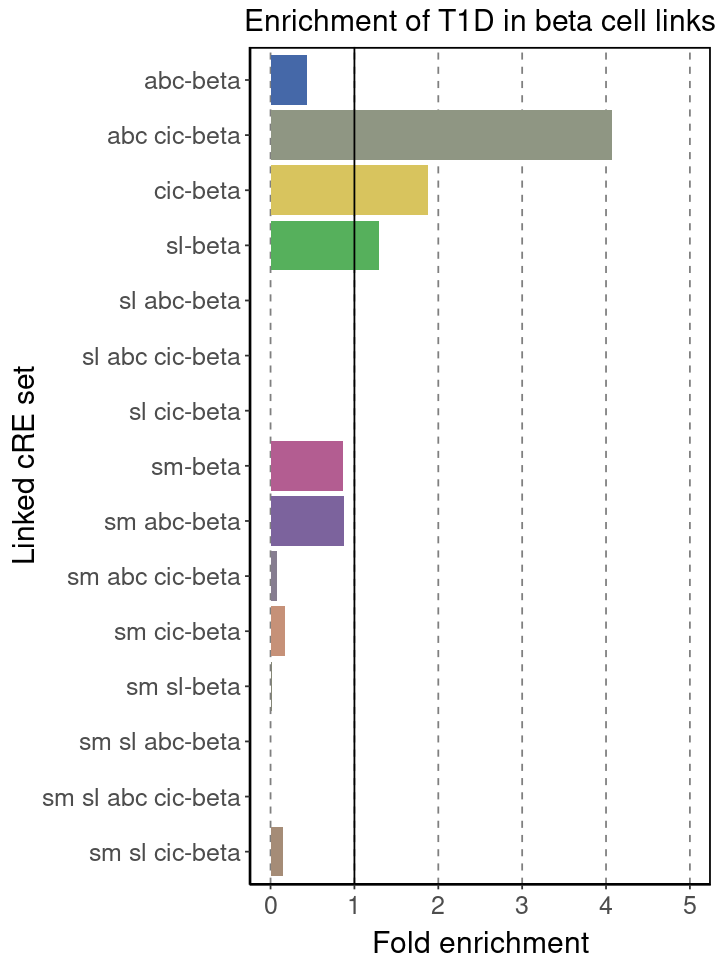

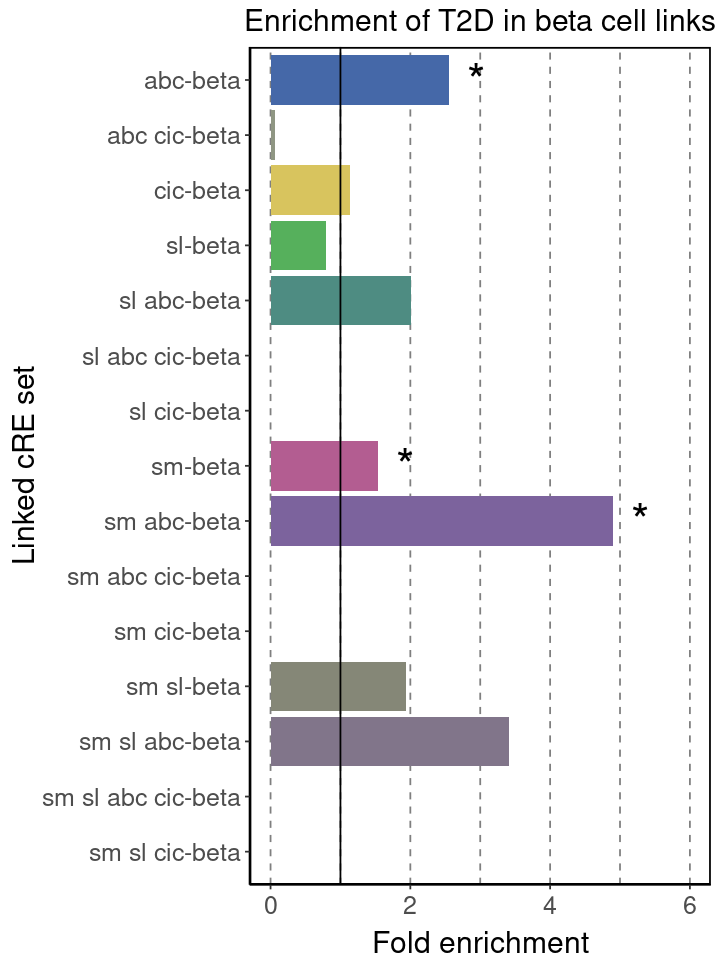

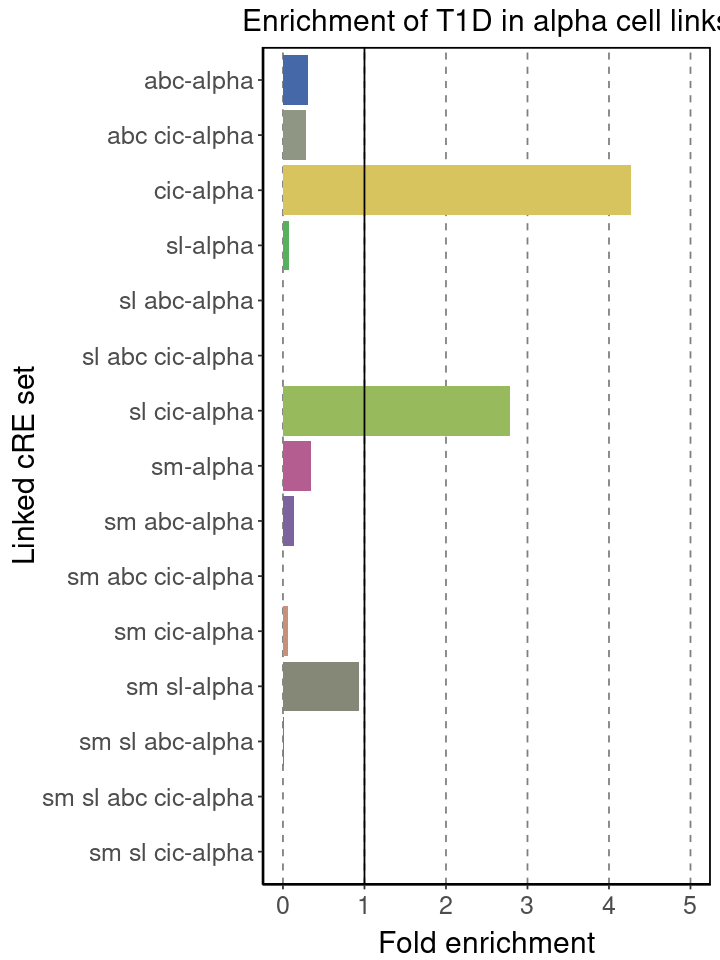

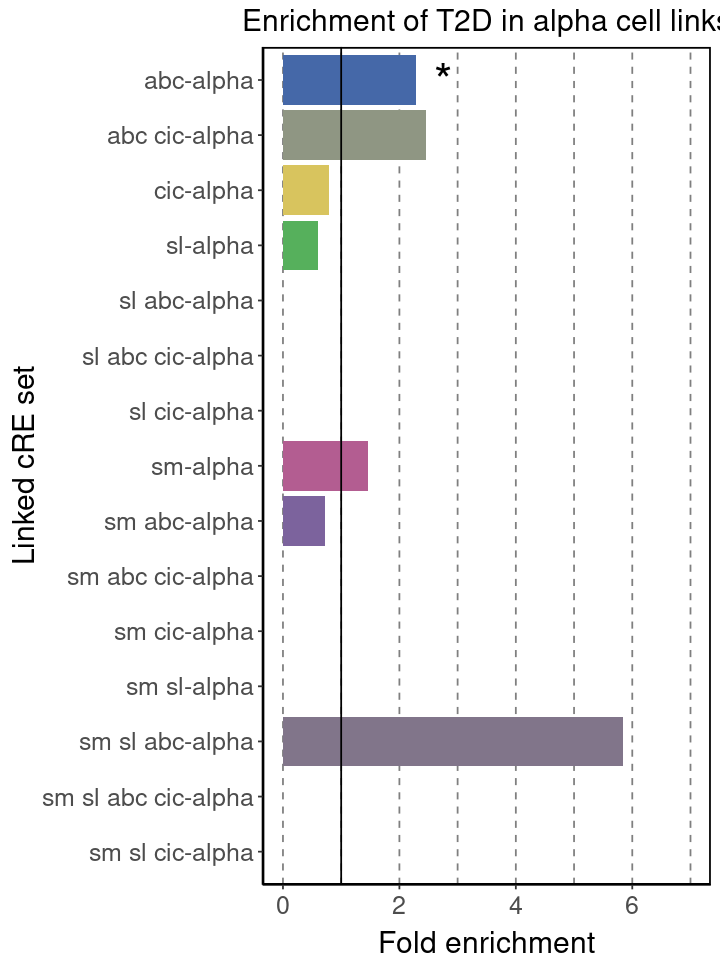

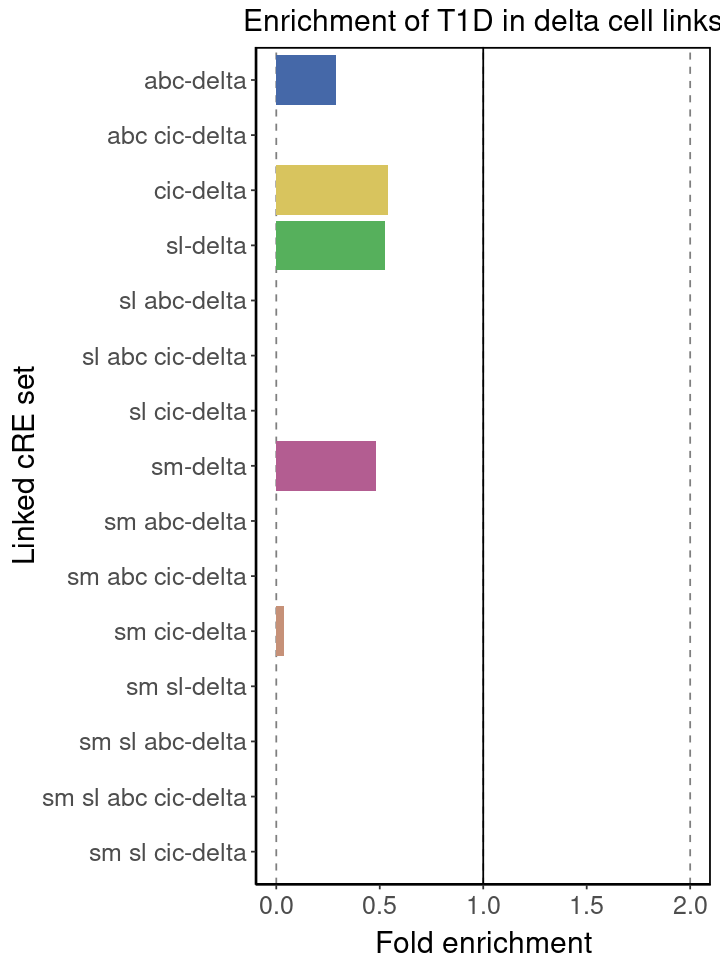

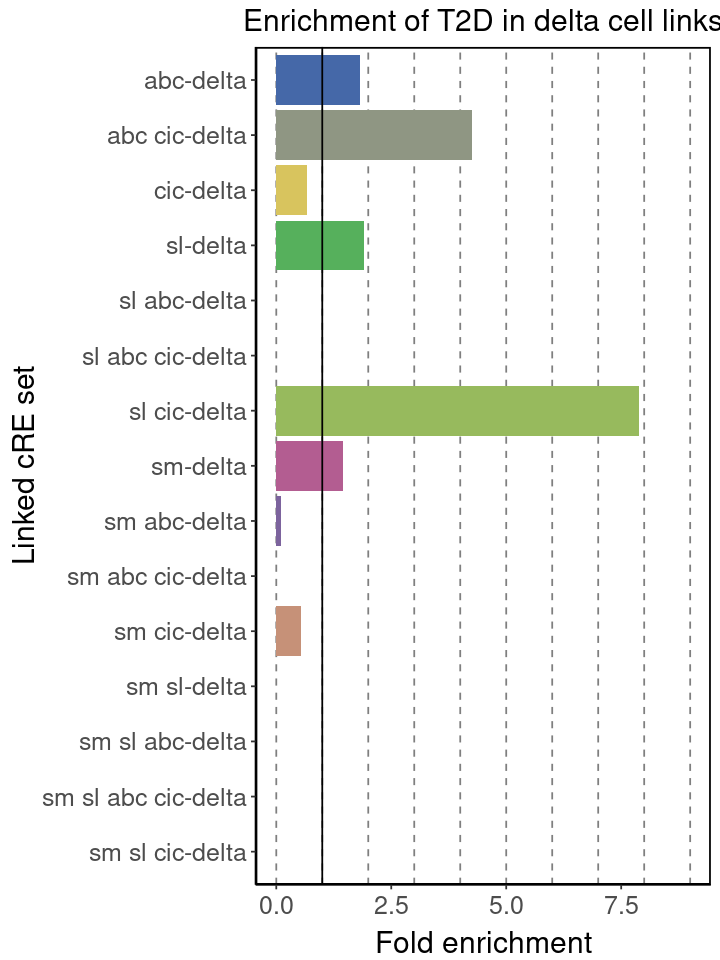

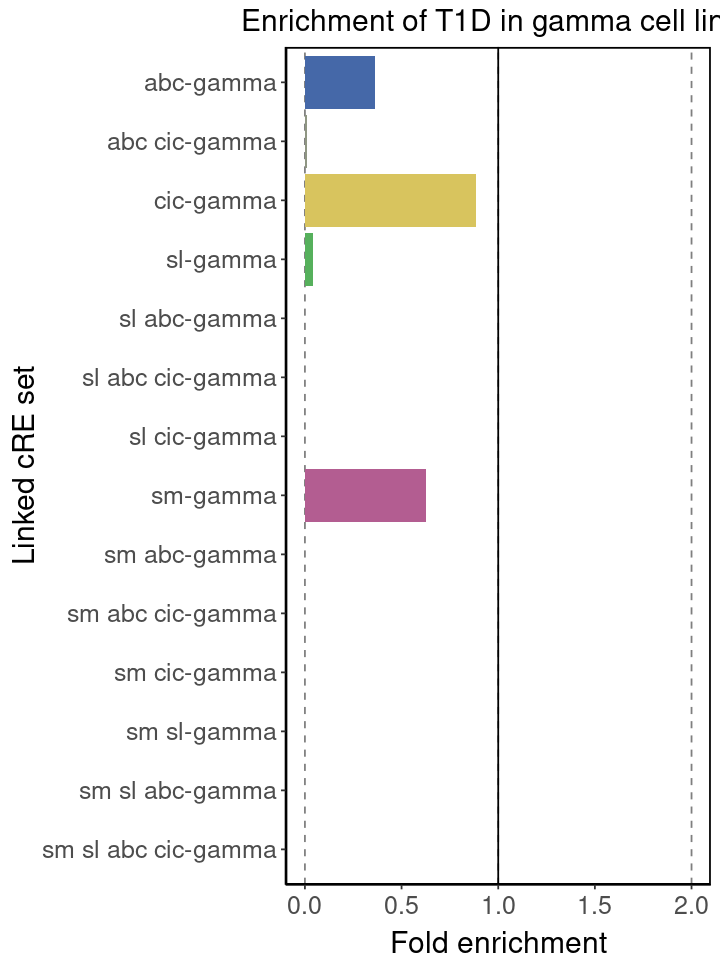

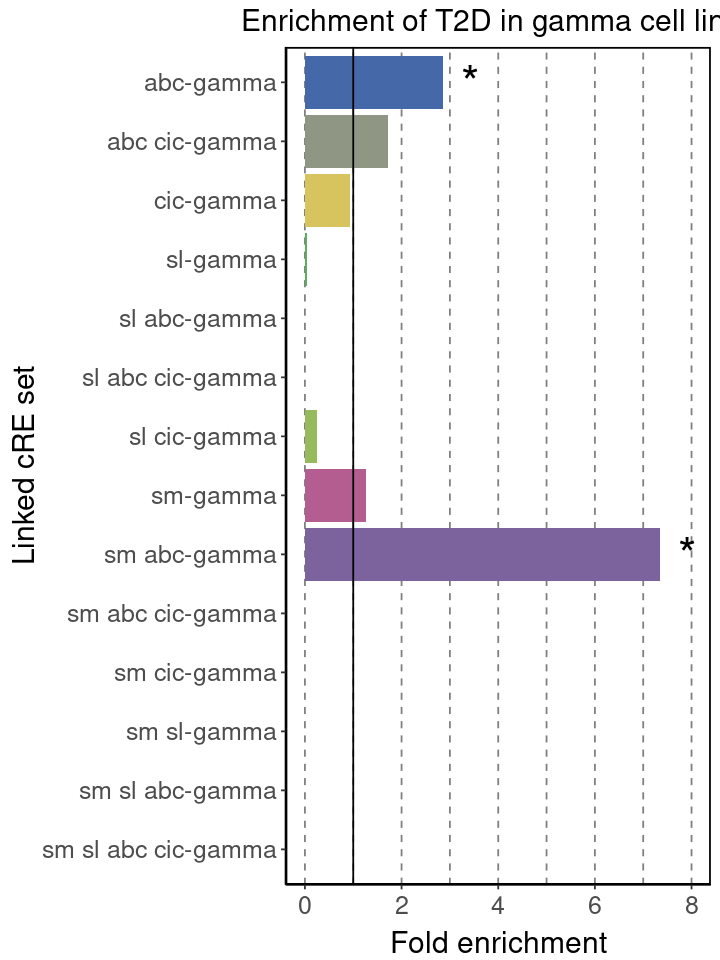

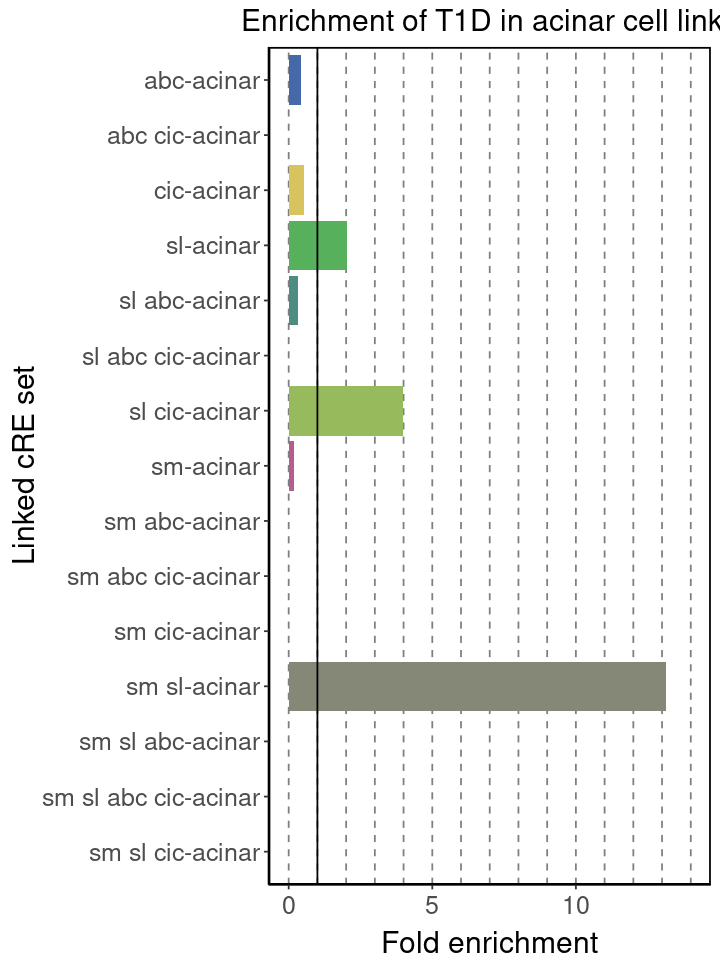

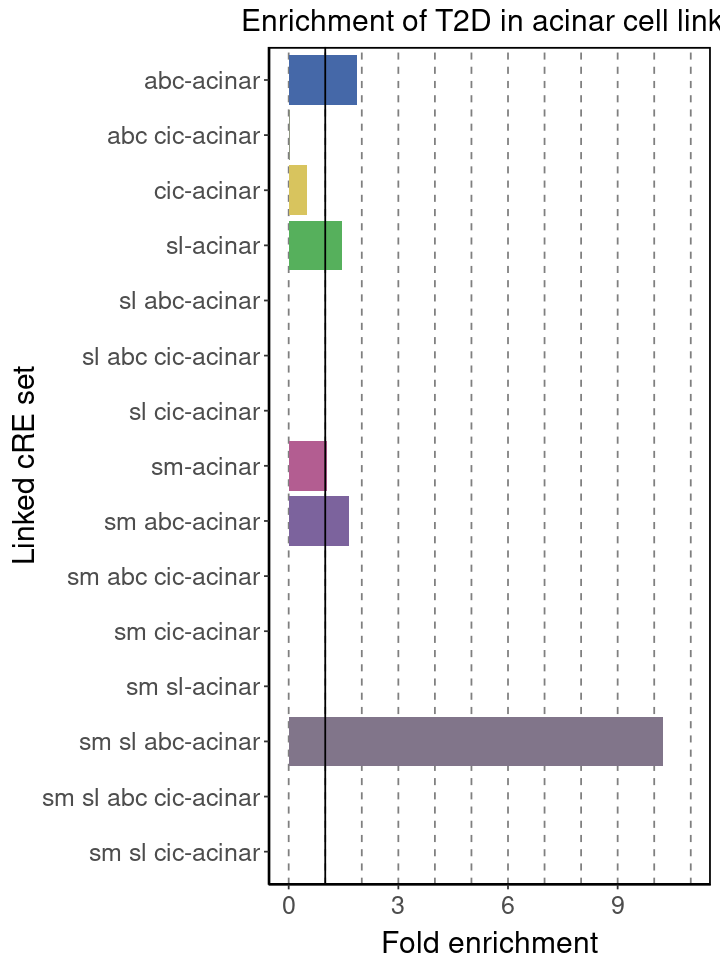

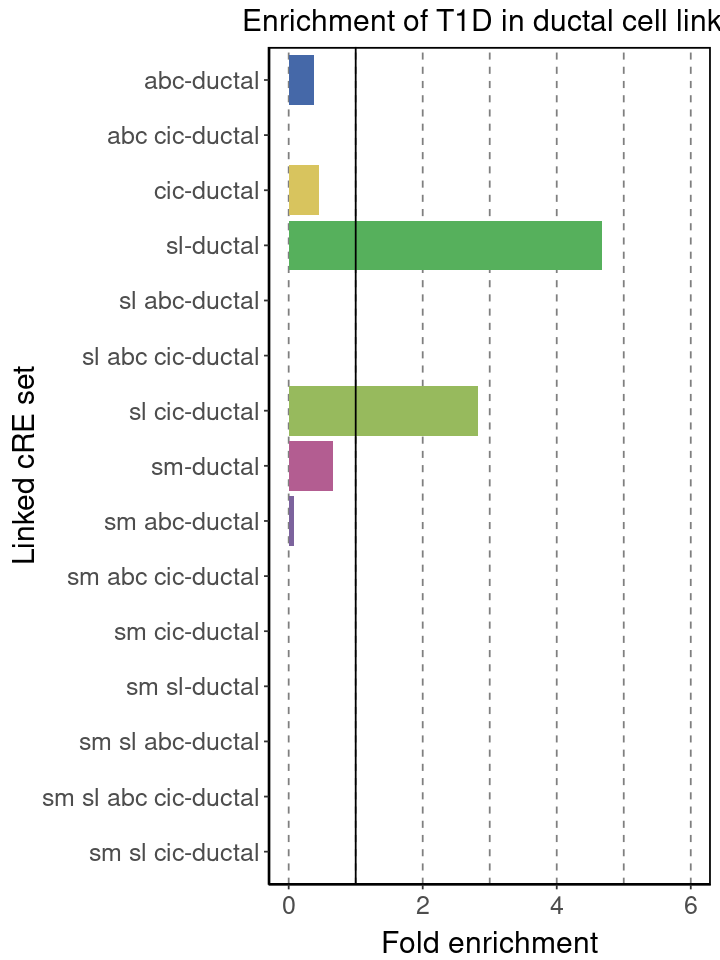

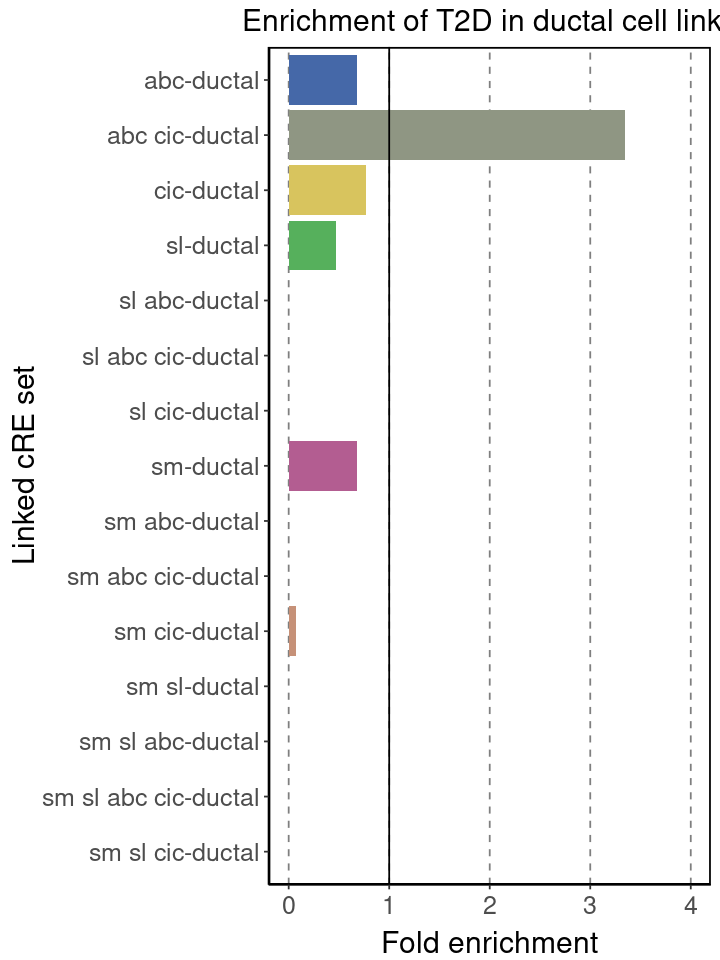

In [32]:
indir <- res_dir2
fp1 <- file.path(indir, 'T1D', 'combined_results_reformat.txt')
fp2 <- file.path(indir, 'T2D', 'combined_results_reformat.txt')

for (celltype in celltypes){
    #make colors vector for specific cell type and use names to cut down plots
    colors2 <- copy(overlap_colors)    
    names(colors2) <- paste(link_sets, celltype, sep='-')
    plot_finrich(fp1, colors2, names(colors2), sprintf('Enrichment of T1D in %s cell links',celltype))
    plot_finrich(fp2, colors2, names(colors2), sprintf('Enrichment of T2D in %s cell links',celltype))
}

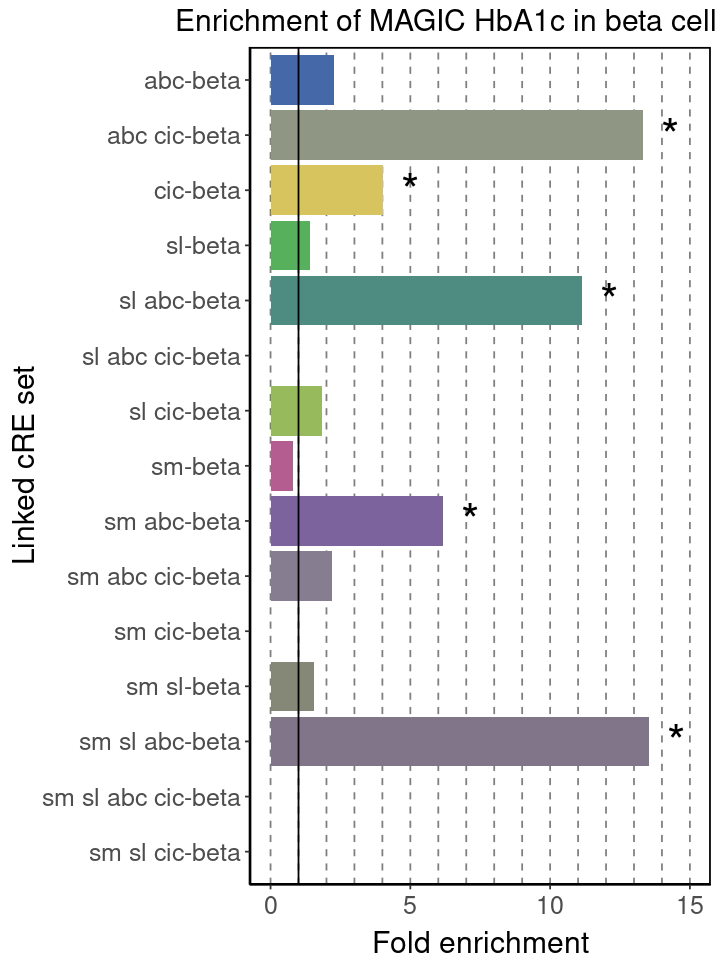

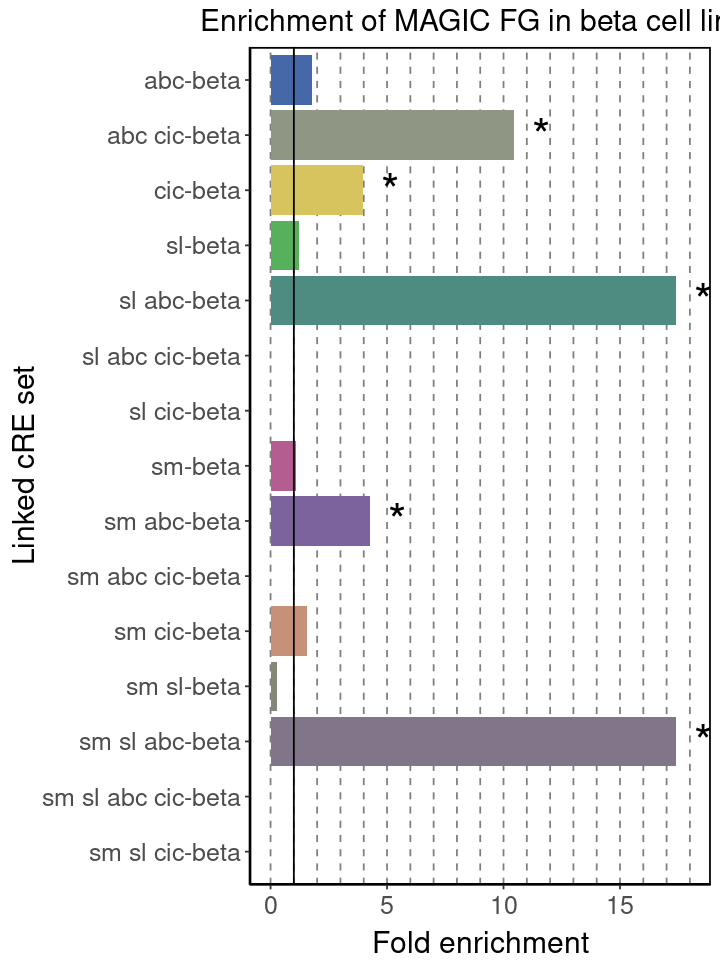

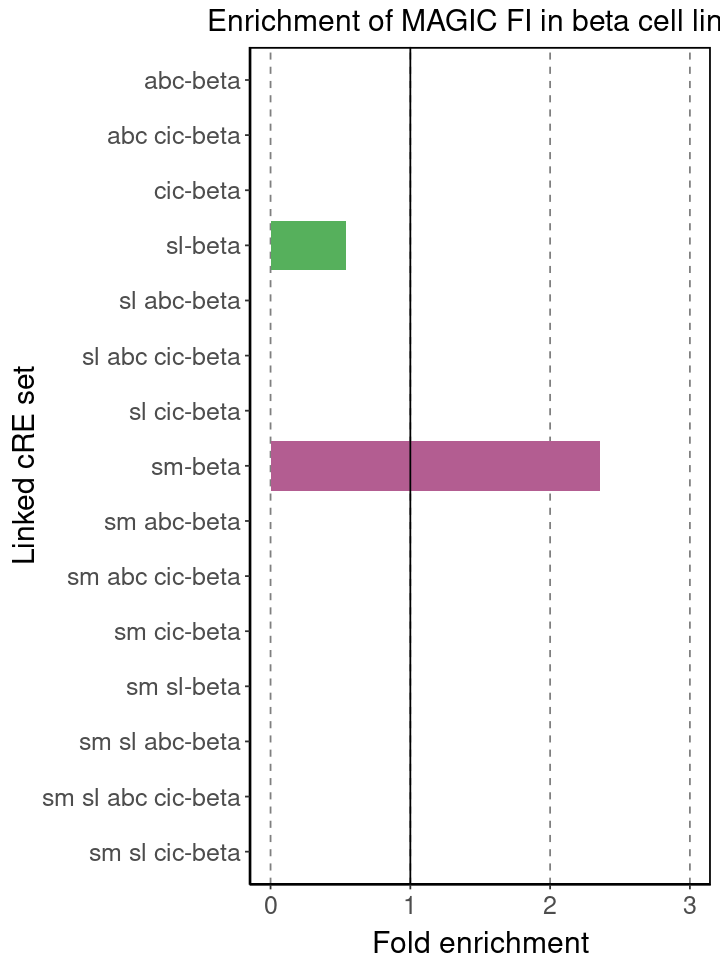

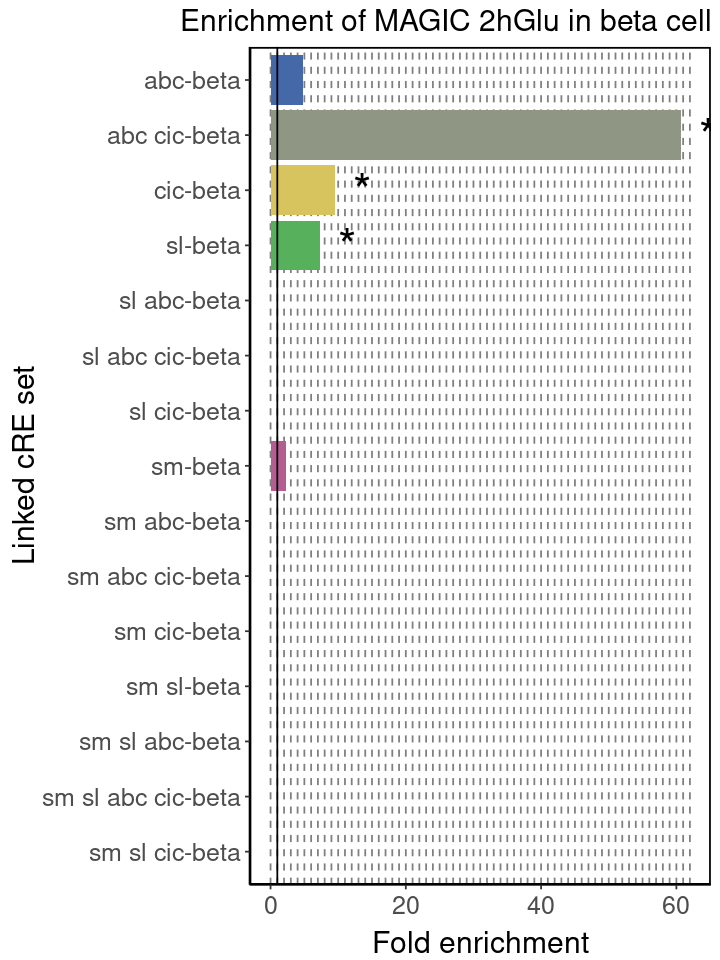

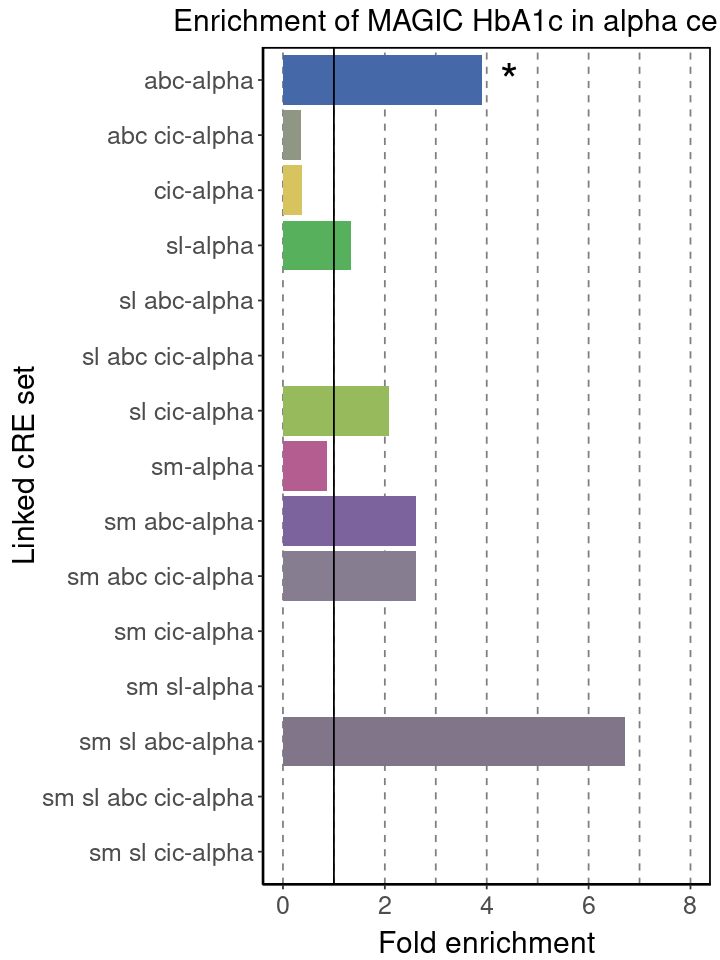

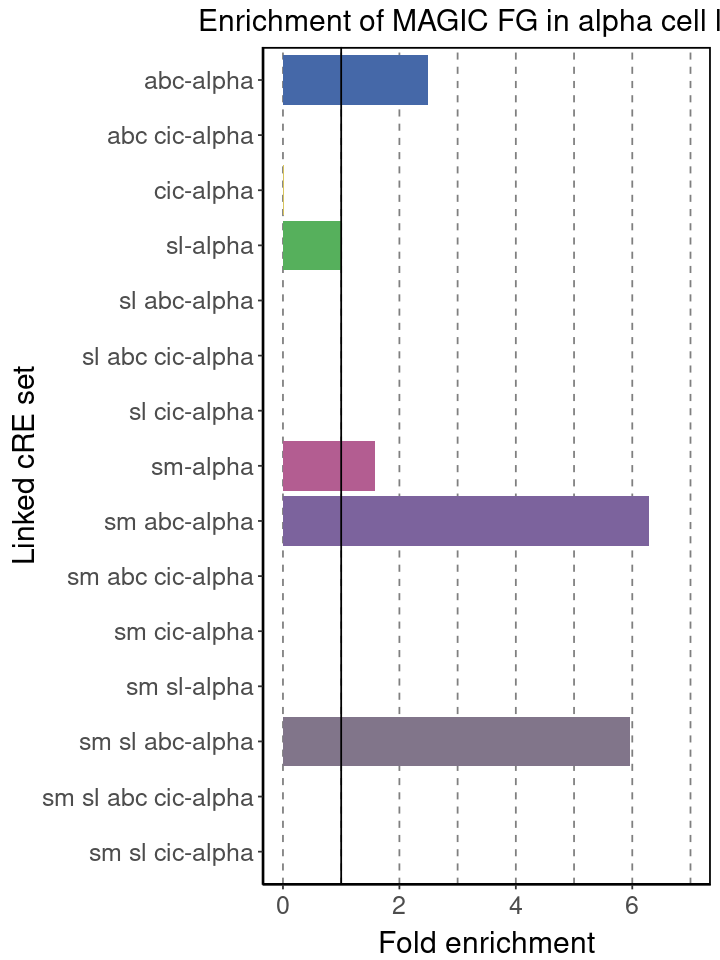

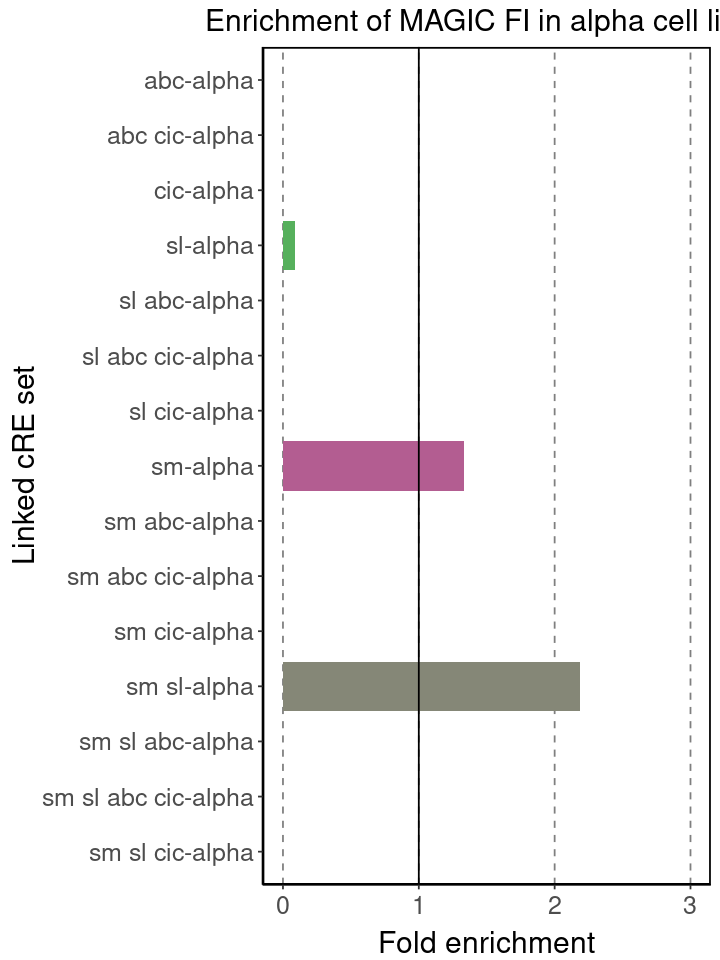

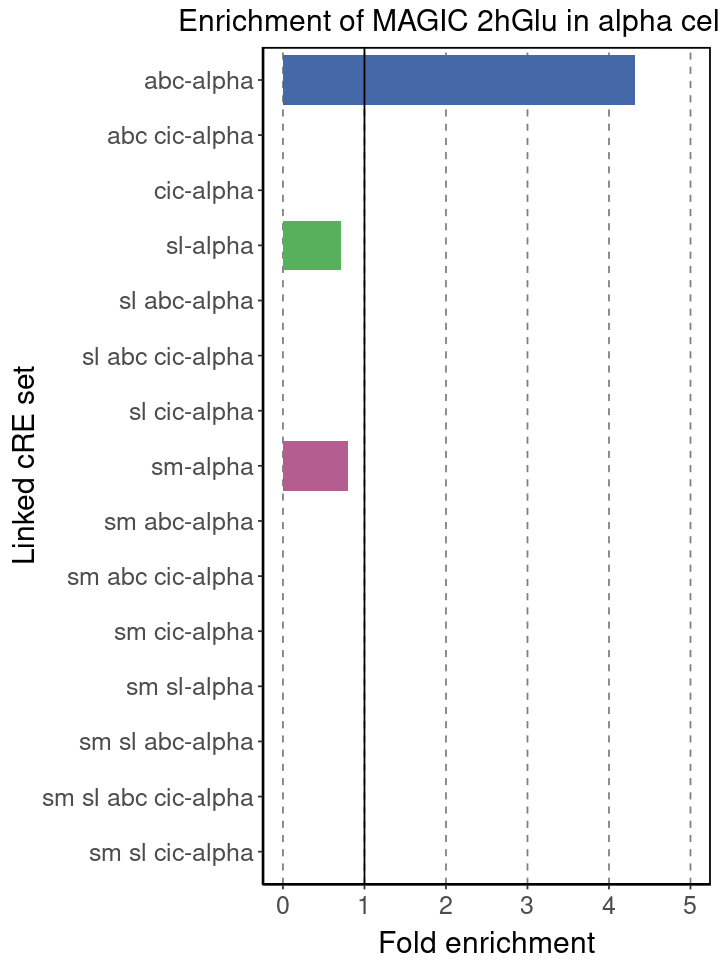

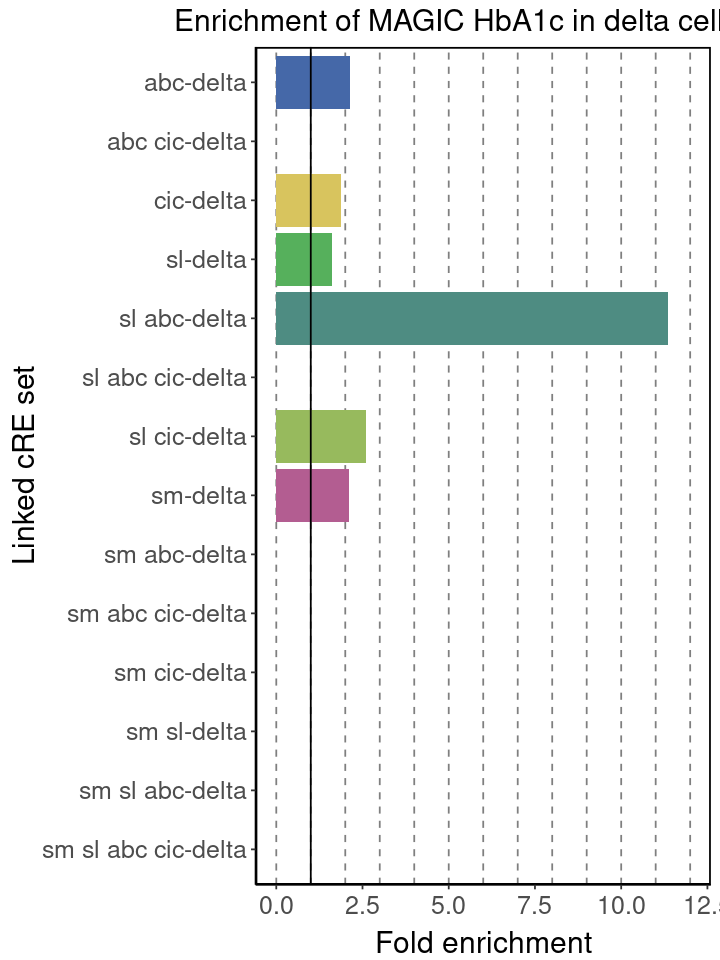

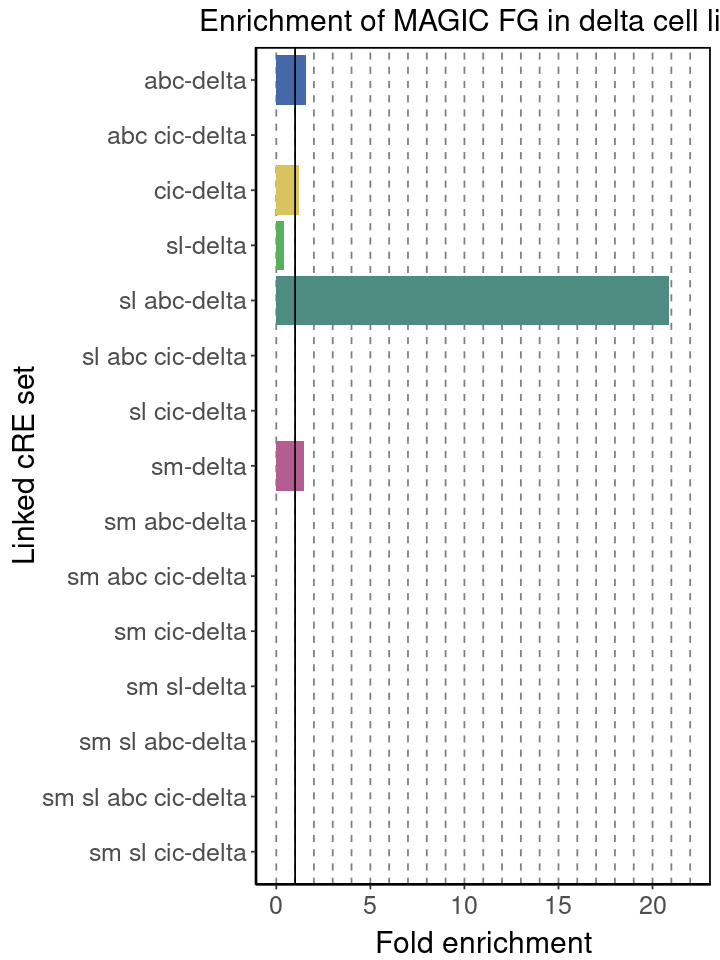

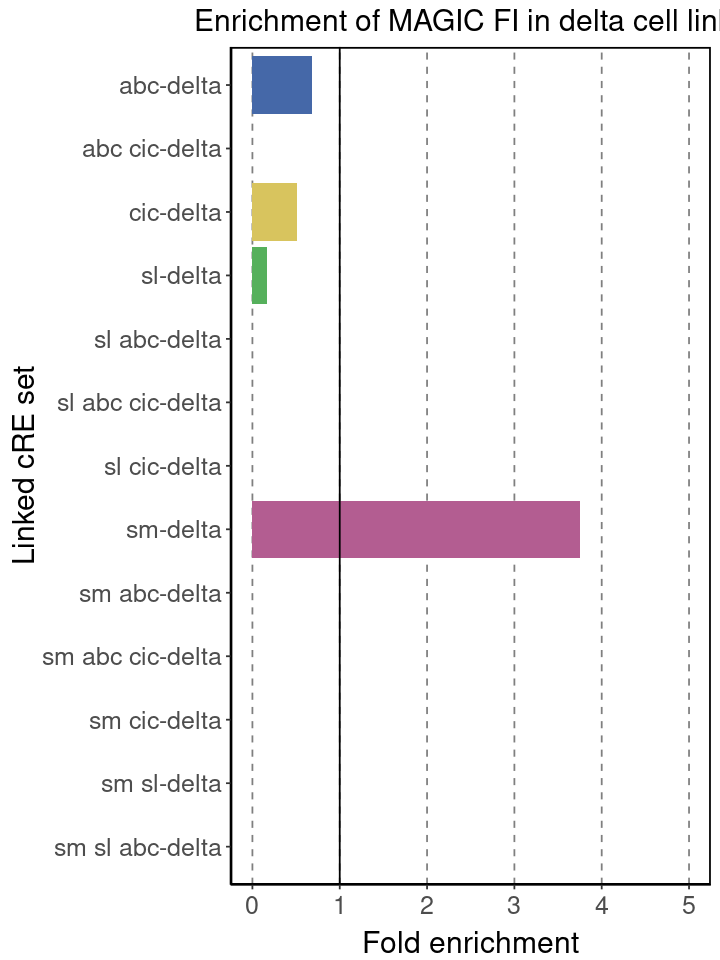

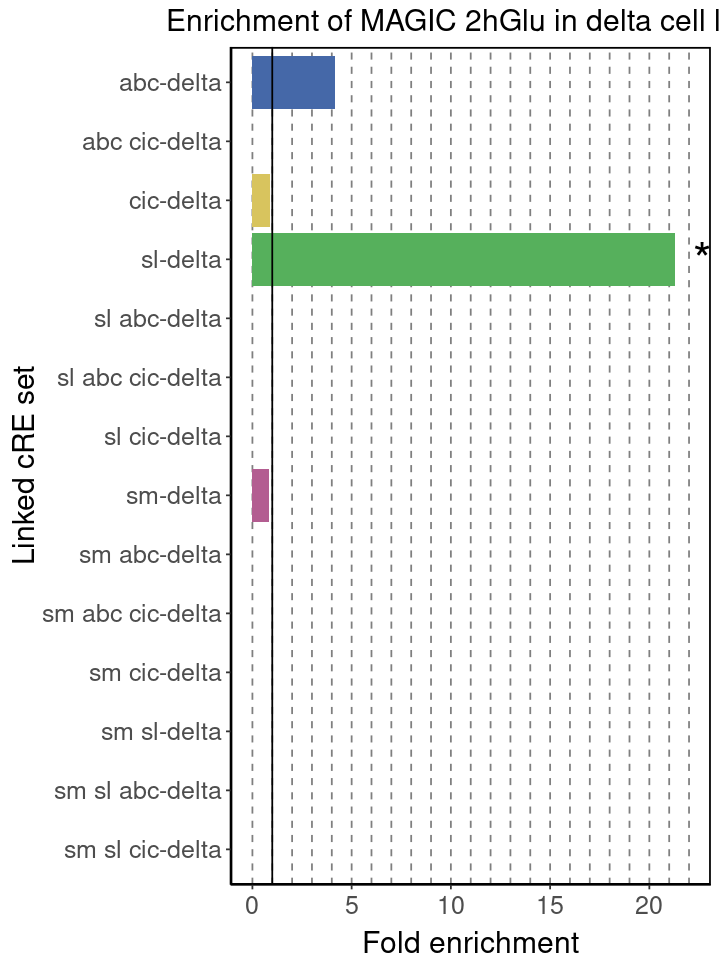

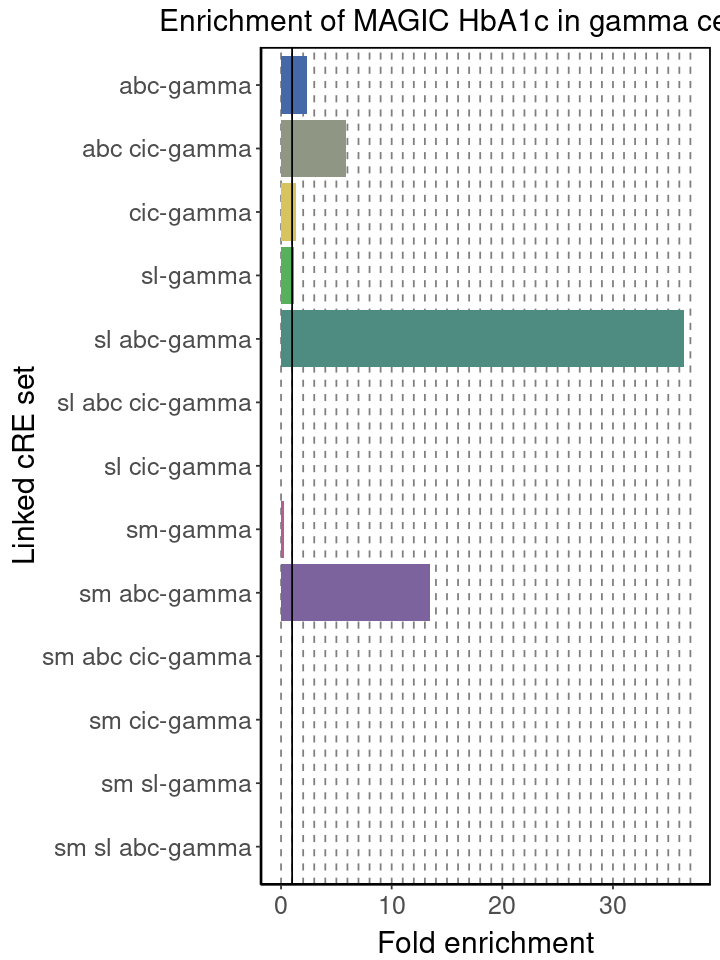

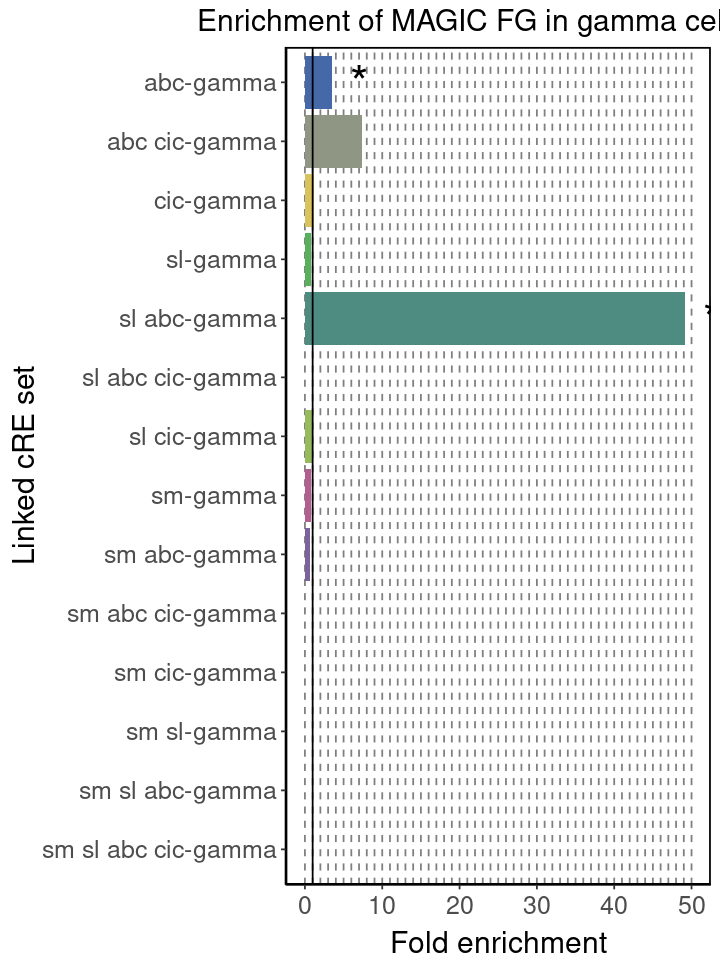

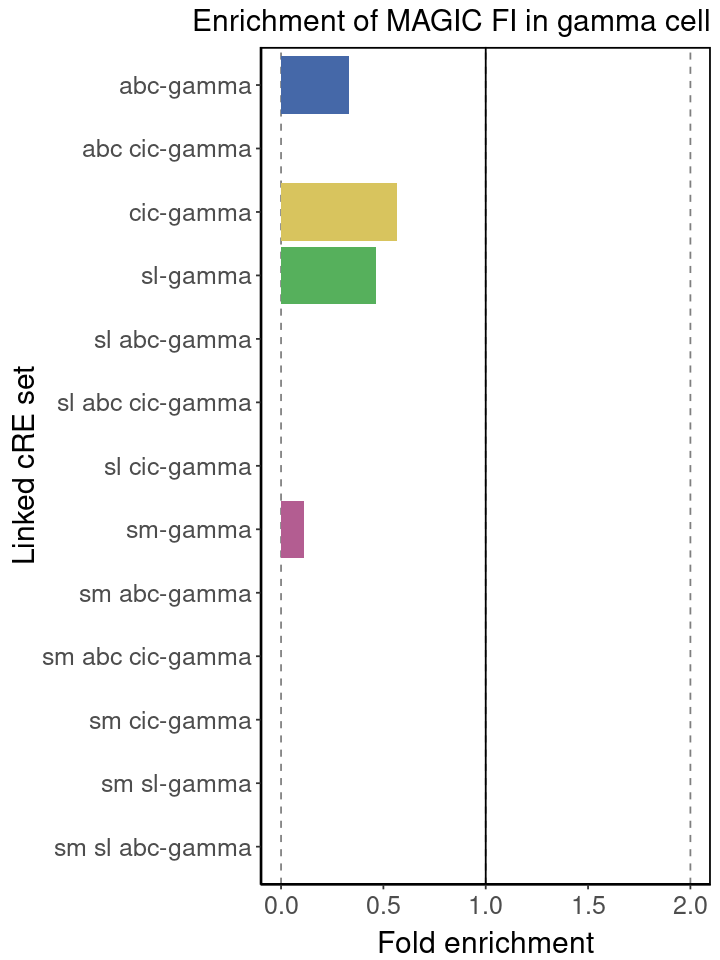

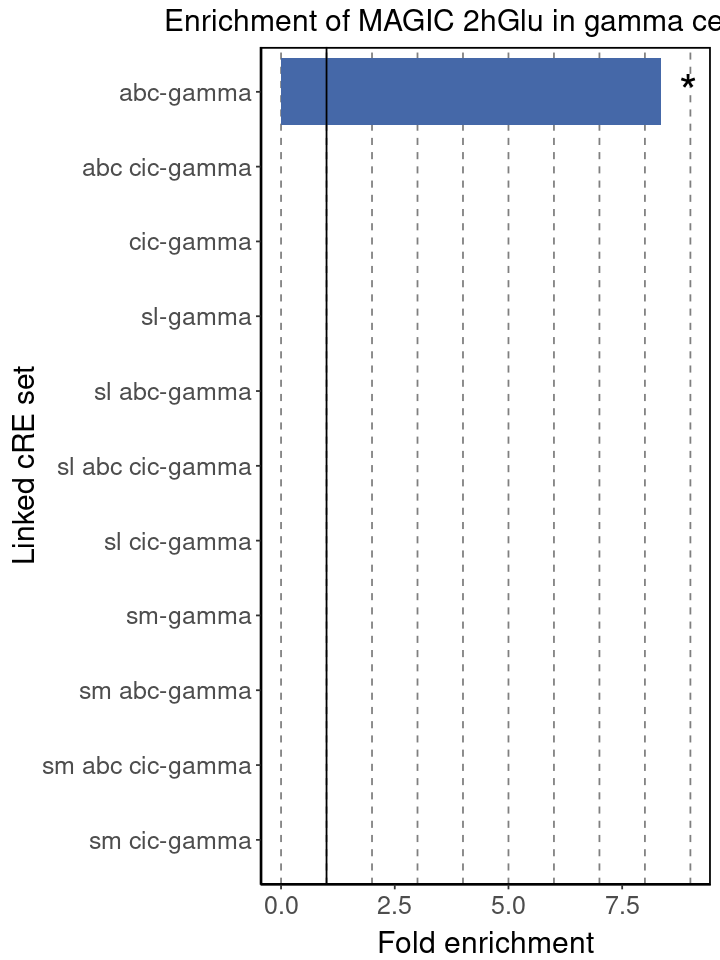

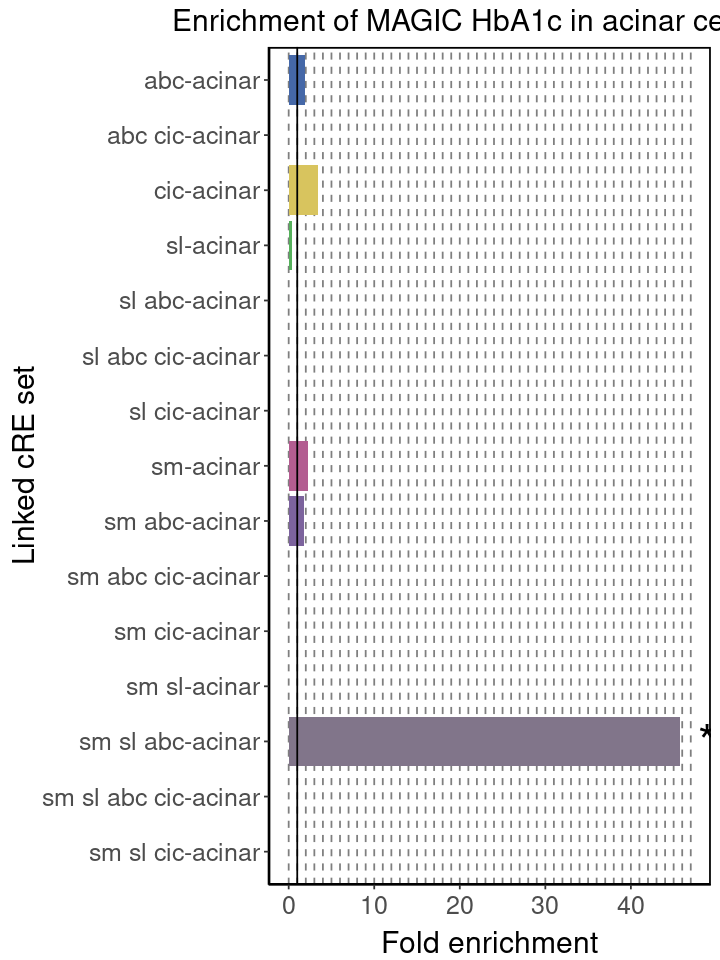

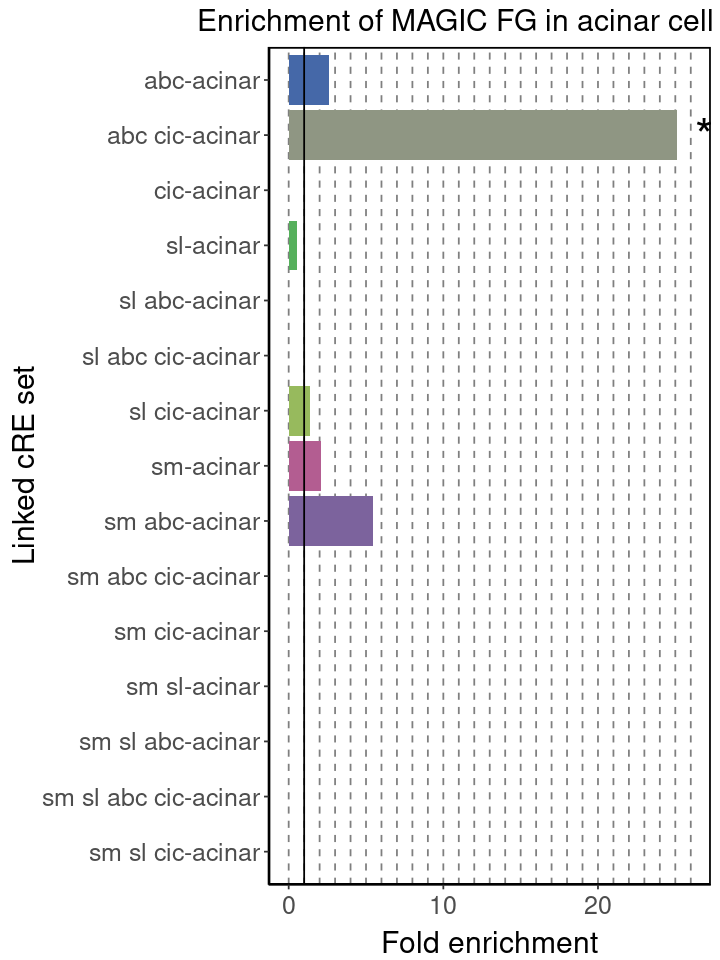

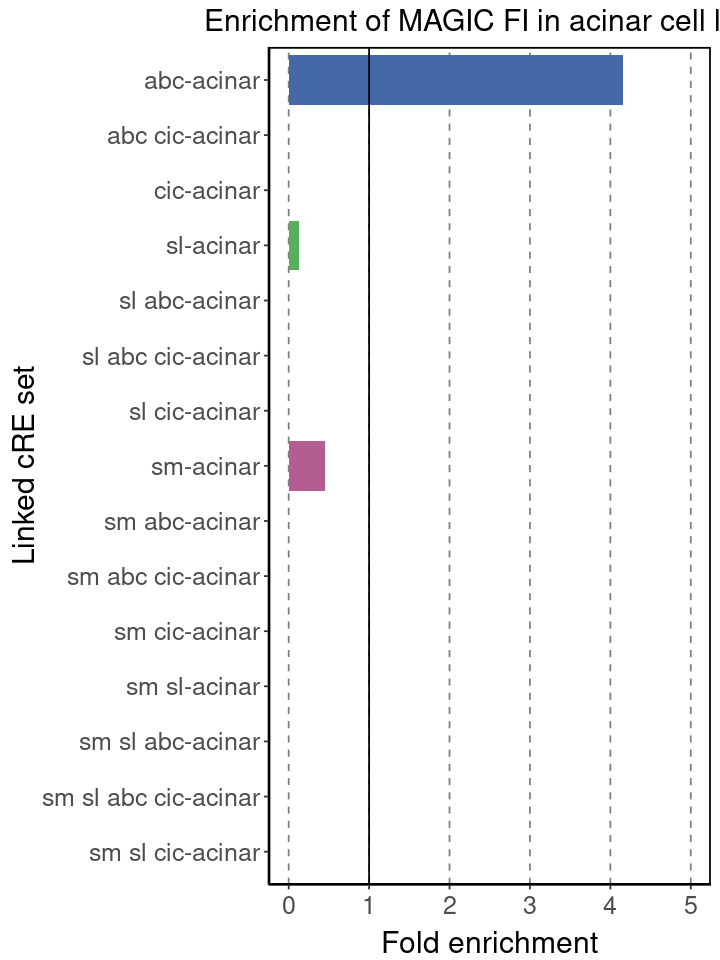

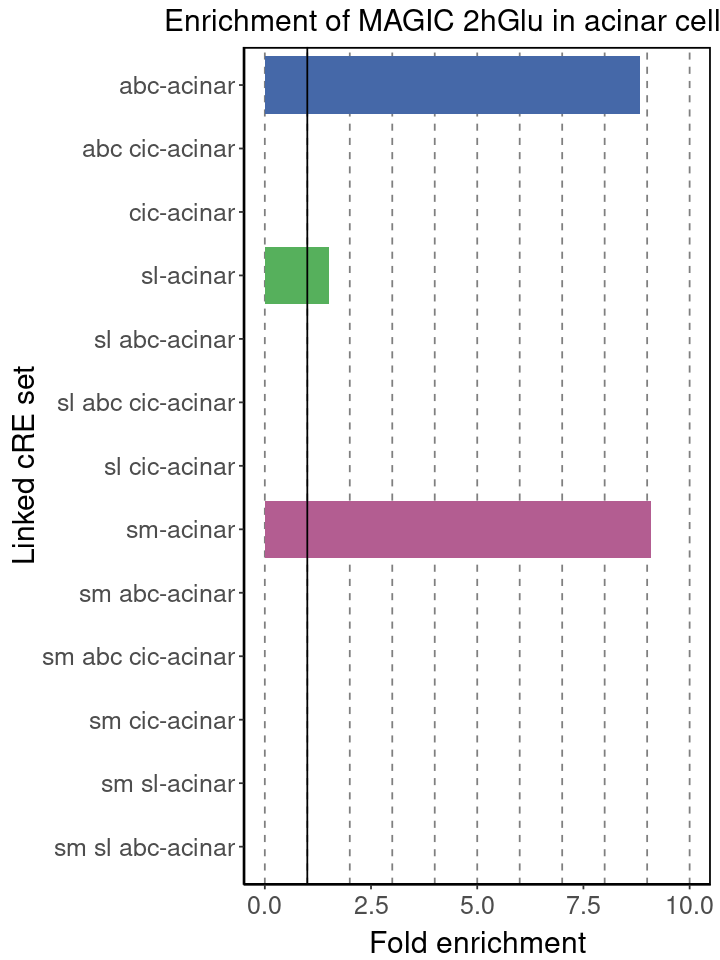

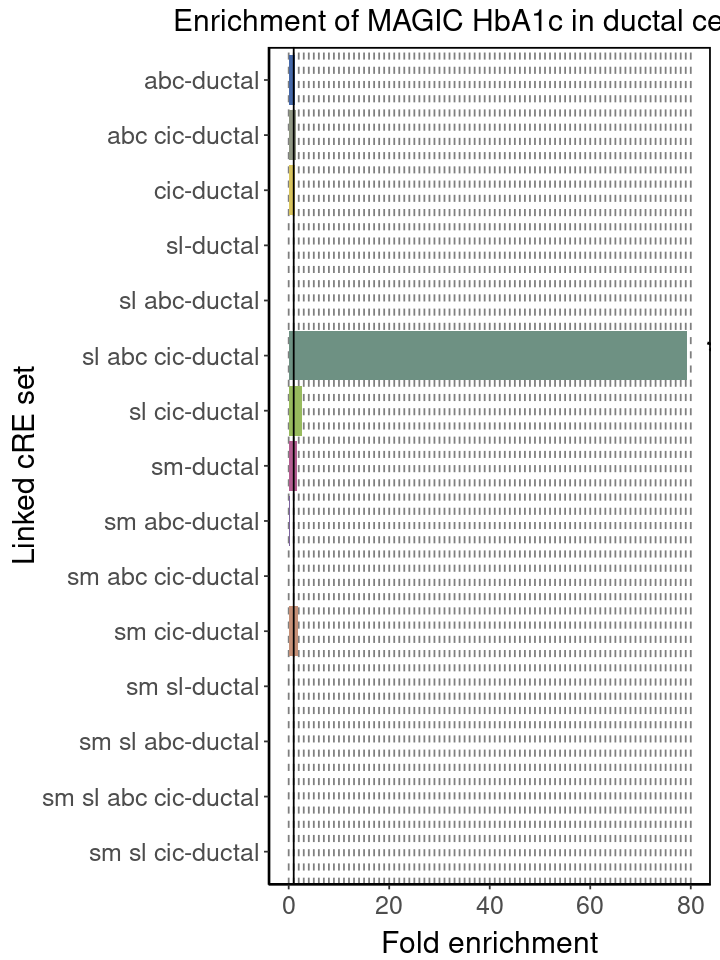

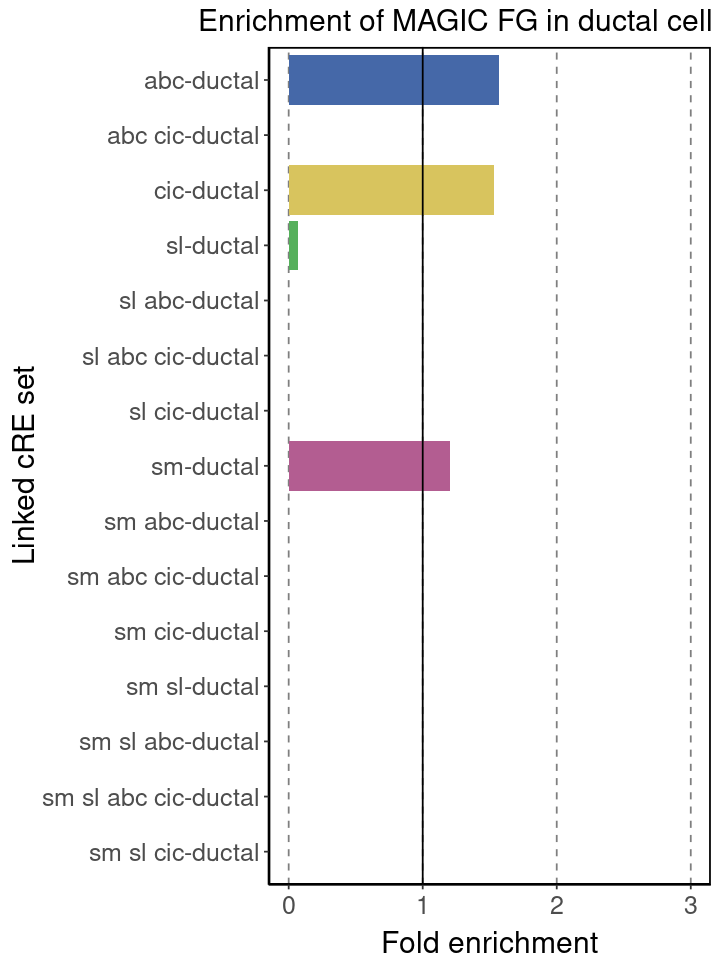

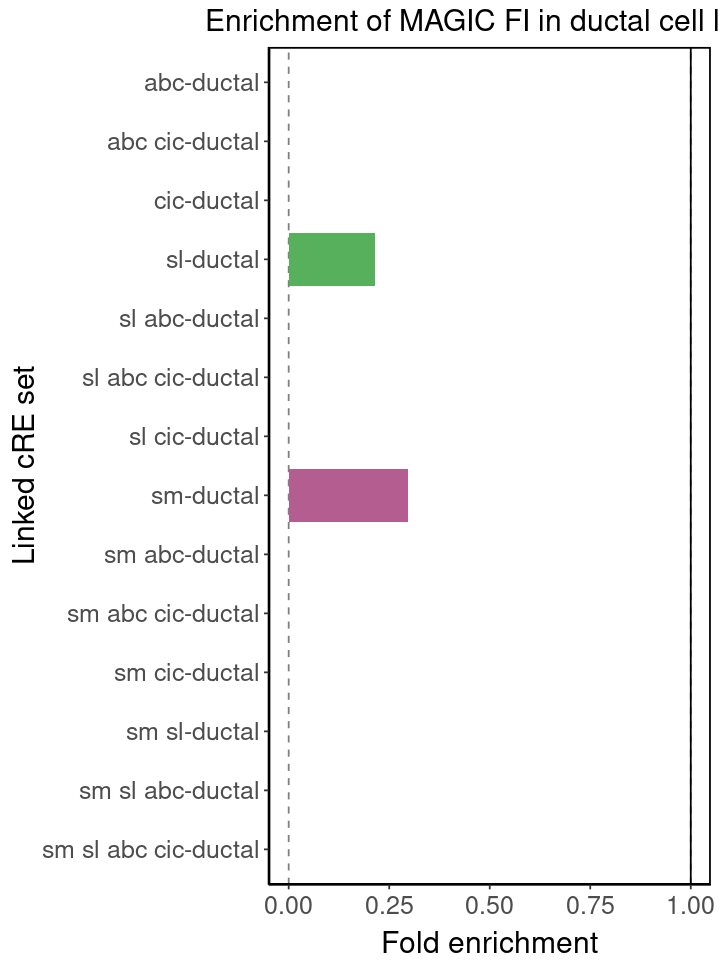

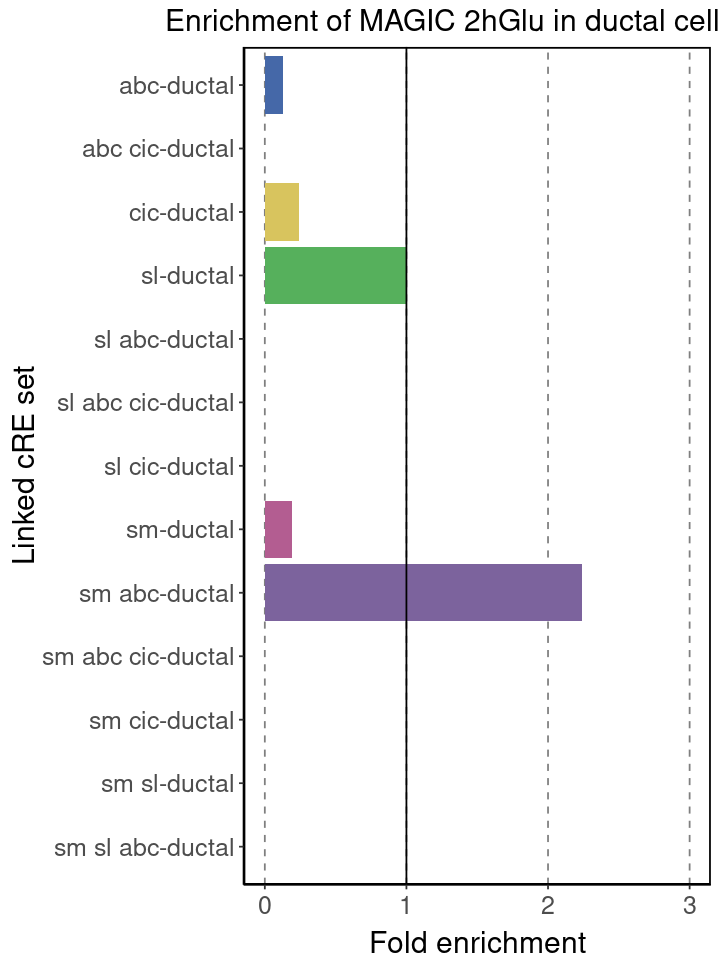

In [33]:
indir <- res_dir2
fp1 <- file.path(indir, 'HbA1c', 'combined_results_reformat.txt')
fp2 <- file.path(indir, 'FG', 'combined_results_reformat.txt')
fp3 <- file.path(indir, 'FI', 'combined_results_reformat.txt')
fp4 <- file.path(indir, '2hGlu', 'combined_results_reformat.txt')

for (celltype in celltypes){
    #make colors vector for specific cell type and use names to cut down plots
    colors2 <- copy(overlap_colors)    
    names(colors2) <- paste(link_sets, celltype, sep='-')
    plot_finrich(fp1, colors2, names(colors2), sprintf('Enrichment of MAGIC HbA1c in %s cell links',celltype))
    plot_finrich(fp2, colors2, names(colors2), sprintf('Enrichment of MAGIC FG in %s cell links',celltype))
    plot_finrich(fp3, colors2, names(colors2), sprintf('Enrichment of MAGIC FI in %s cell links',celltype))
    plot_finrich(fp4, colors2, names(colors2), sprintf('Enrichment of MAGIC 2hGlu in %s cell links',celltype))
}

In [2]:
sessionInfo()

R version 4.1.1 (2021-08-10)
Platform: x86_64-pc-linux-gnu (64-bit)
Running under: Ubuntu 20.04.2 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/blas/libblas.so.3.9.0
LAPACK: /usr/lib/x86_64-linux-gnu/lapack/liblapack.so.3.9.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] parallel  grid      stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
[1] RColorBrewer_1.1-3 ggplot2_3.4.4      UpSetR_1.4.0       tictoc_1.1        
[5] data.table_1.14.8  stringr_1.4.1      dplyr_1.0.10      

loaded via a namespace (and not attached):
 [1] Rcpp_1.0.13       plyr_1.8.9        pillar_1.8.1      